<a href="https://colab.research.google.com/github/fahimrayhan/vidhance-extendview/blob/fahim-explore/Thermal_Guided_RGBT_UAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermal-Guided RGB Enhancement + RGB-T Video Demo

This notebook is a **first working prototype** for an aligned RGB + thermal UAV system.

Pipeline:

**aligned RGB + thermal → lightweight dual encoder → gated/difference fusion → RGB enhancement → optional YOLO detection → output video**

In [1]:
# 1. Install dependencies
!pip -q install opencv-python-headless matplotlib tqdm ultralytics gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.7 MB/s eta 0:00:00


In [2]:
# 2. Imports and runtime
import os, glob, time, math, random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!rm -rf /content/data && unzip -q /content/drive/MyDrive/Datasets/RGBTDronePerson/RGBTDronePerson.zip -d /content/data && echo "Done."

Done.


## 4. dataset paths

In [5]:

RGB_DIR = "/content/data/train/visible"
THERMAL_DIR = "/content/data/train/thermal"

# If your images are inside Google Drive:
# RGB_DIR = "/content/drive/MyDrive/VTUB/rgb"
# THERMAL_DIR = "/content/drive/MyDrive/VTUB/thermal"

IMG_SIZE = 320
BATCH_SIZE = 16
NUM_WORKERS = 0

In [6]:
# 5. Pair discovery + visualization utilities
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def find_images(root):
    root = Path(root)
    files = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    return sorted(files)

def make_pair_index(rgb_dir, thermal_dir):
    rgb_files = find_images(rgb_dir)
    th_files = find_images(thermal_dir)

    # Match by filename stem first.
    th_map = {p.stem: p for p in th_files}
    pairs = [(p, th_map[p.stem]) for p in rgb_files if p.stem in th_map]

    print(f"RGB images     : {len(rgb_files)}")
    print(f"Thermal images : {len(th_files)}")
    print(f"Matched pairs  : {len(pairs)}")

    if len(pairs) == 0:
        print("\nNo pairs found. Check the two paths and filename conventions.")
    return pairs

pairs = make_pair_index(RGB_DIR, THERMAL_DIR)

RGB images     : 4900
Thermal images : 4900
Matched pairs  : 4900


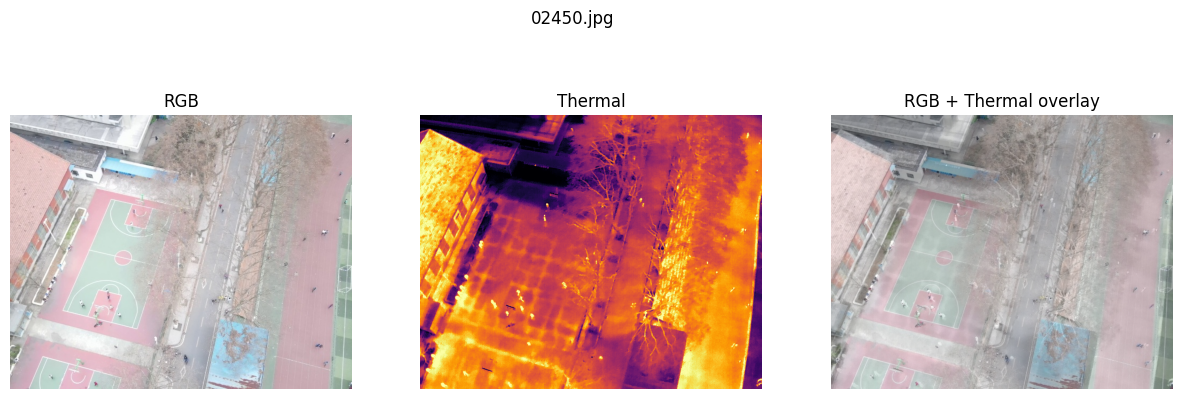

In [7]:
def read_rgb(path):
    x = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if x is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

def read_thermal(path):
    x = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if x is None:
        raise FileNotFoundError(path)

    if x.ndim == 3:
        x = cv2.cvtColor(x, cv2.COLOR_BGR2GRAY)

    x = x.astype(np.float32)
    mn, mx = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - mn) / max(mx - mn, 1e-6), 0, 1)
    return x

def show_pair(pair, title=""):
    rgb = read_rgb(pair[0])
    th = read_thermal(pair[1])

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(rgb); ax[0].set_title("RGB"); ax[0].axis("off")
    ax[1].imshow(th, cmap="inferno"); ax[1].set_title("Thermal"); ax[1].axis("off")

    thermal_vis = np.uint8(th * 255)
    thermal_vis = cv2.cvtColor(thermal_vis, cv2.COLOR_GRAY2RGB)
    overlay = cv2.addWeighted(rgb, 0.65, thermal_vis, 0.35, 0)
    ax[2].imshow(overlay); ax[2].set_title("RGB + Thermal overlay"); ax[2].axis("off")

    plt.suptitle(title or pair[0].name)
    plt.show()

if pairs:
    show_pair(pairs[len(pairs)//2])

## 6. Synthetic haze

Because the first dataset may not contain clean/hazy frame pairs, we create a differentiable-ish synthetic haze transformation:

`I_hazy = I_clear * t + A * (1 - t)`

where `t` is a transmission map and `A` is atmospheric light.

Thermal is passed unchanged and can guide the restoration network.

In [15]:
def add_synthetic_haze(rgb):
    # rgb: [B,3,H,W], range [0,1]
    B, _, H, W = rgb.shape
    severity = torch.rand(B, 1, 1, 1, device=rgb.device) * 0.55 + 0.25

    # Random smooth-ish depth/transmission proxy.
    small_h, small_w = max(4, H // 32), max(4, W // 32)
    noise = torch.rand(B, 1, small_h, small_w, device=rgb.device)
    noise = F.interpolate(noise, size=(H, W), mode="bilinear", align_corners=False)

    t = 1.0 - severity * (0.65 + 0.35 * noise)
    t = torch.clamp(t, 0.15, 0.95)

    A = torch.rand(B, 3, 1, 1, device=rgb.device) * 0.12 + 0.82
    hazy = rgb * t + A * (1 - t)

    # Occasionally lower contrast to imitate poor visibility.
    contrast = torch.rand(B, 1, 1, 1, device=rgb.device) * 0.25 + 0.80
    hazy = torch.clamp((hazy - 0.5) * contrast + 0.5, 0, 1)

    return hazy

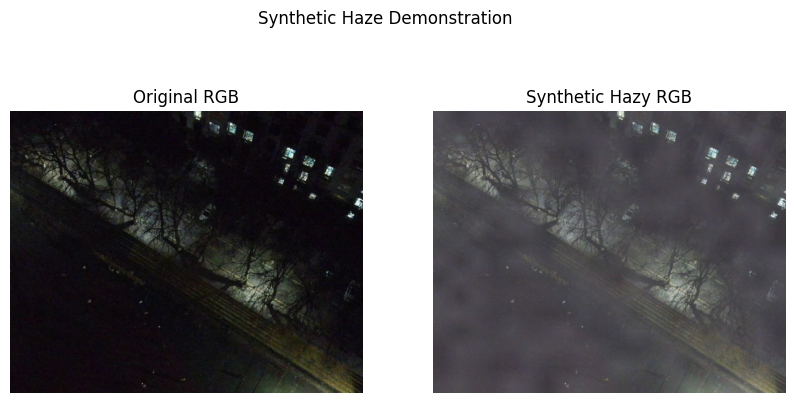

In [16]:
if pairs:
    # Load a sample RGB image
    rgb_sample = read_rgb(pairs[0][0])
    rgb_tensor = torch.from_numpy(rgb_sample).permute(2,0,1).float().unsqueeze(0) / 255.0

    # Apply synthetic haze
    hazy_tensor = add_synthetic_haze(rgb_tensor)
    hazy_sample = hazy_tensor.squeeze(0).permute(1,2,0).cpu().numpy()

    # Plot side-by-side comparison
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(rgb_sample)
    ax[0].set_title("Original RGB")
    ax[0].axis("off")

    ax[1].imshow(hazy_sample)
    ax[1].set_title("Synthetic Hazy RGB")
    ax[1].axis("off")

    plt.suptitle("Synthetic Haze Demonstration")
    plt.show()
else:
    print("No matched image pairs available to test.")

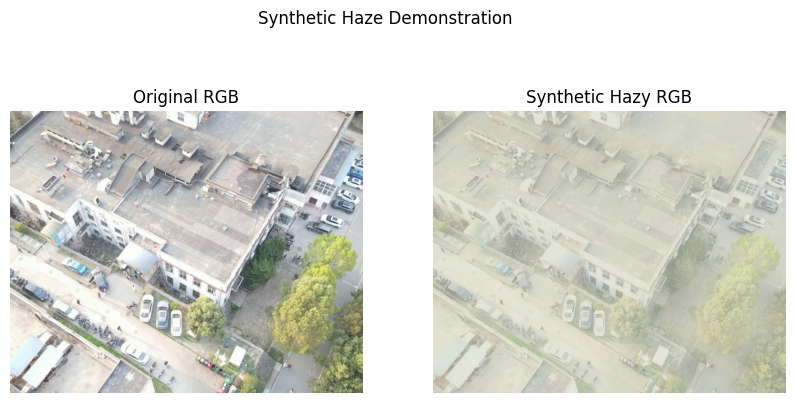

In [17]:
if pairs:
    # Load a sample RGB image
    rgb_sample = read_rgb(pairs[70][0])
    rgb_tensor = torch.from_numpy(rgb_sample).permute(2,0,1).float().unsqueeze(0) / 255.0

    # Apply synthetic haze
    hazy_tensor = add_synthetic_haze(rgb_tensor)
    hazy_sample = hazy_tensor.squeeze(0).permute(1,2,0).cpu().numpy()

    # Plot side-by-side comparison
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(rgb_sample)
    ax[0].set_title("Original RGB")
    ax[0].axis("off")

    ax[1].imshow(hazy_sample)
    ax[1].set_title("Synthetic Hazy RGB")
    ax[1].axis("off")

    plt.suptitle("Synthetic Haze Demonstration")
    plt.show()
else:
    print("No matched image pairs available to test.")

## 7. Dataset

The network sees:

- hazy RGB
- thermal

and learns to reconstruct:

- clean/original RGB

The thermal branch is therefore used as a **structural guide**.

In [18]:
class PairedRGBTDataset(Dataset):
    def __init__(self, pairs, img_size=320):
        self.pairs = pairs
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        rgb_p, th_p = self.pairs[idx]

        rgb = read_rgb(rgb_p)
        th = read_thermal(th_p)

        # Resize while keeping RGB/T spatially aligned.
        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        th = cv2.resize(th, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

        rgb = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0
        th = torch.from_numpy(th)[None].float()

        # Simple random horizontal flip; applied to BOTH modalities.
        if random.random() < 0.5:
            rgb = torch.flip(rgb, dims=[2])
            th = torch.flip(th, dims=[2])

        hazy = add_synthetic_haze(rgb.unsqueeze(0)).squeeze(0)
        return hazy, th, rgb

# Use a subset first so Colab iteration is fast.
random.seed(42)
random.shuffle(pairs)

N_MAX = min(len(pairs), 12000)
pairs_small = pairs[:N_MAX]

n_train = int(0.9 * len(pairs_small))
train_pairs = pairs_small[:n_train]
val_pairs = pairs_small[n_train:]

train_ds = PairedRGBTDataset(train_pairs, IMG_SIZE)
val_ds = PairedRGBTDataset(val_pairs, IMG_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train:", len(train_ds), "Val:", len(val_ds))

Train: 4410 Val: 490


## 8. Lightweight RGB-T model

The design is intentionally small:

1. RGB encoder
2. thermal encoder
3. learned RGB-vs-thermal gate
4. difference feature `|RGB - Thermal|`
5. compact fusion block
6. RGB enhancement decoder

There is **no registration module** because the inputs are already aligned.

In [19]:

# Thermal-Guided Multi-Scale U-Net

class DSConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch, in_ch,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_ch,
                bias=False
            ),
            nn.BatchNorm2d(in_ch),
            nn.SiLU(inplace=True),

            # Pointwise convolution
            nn.Conv2d(
                in_ch, out_ch,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    """
    Feature extractor for either RGB or Thermal.

    RGB:
        3 channels -> features

    Thermal:
        1 channel -> features
    """
    def __init__(self, in_ch):
        super().__init__()

        # 320x320 -> 320x320
        self.block1 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),

            DSConv(32, 32)
        )

        # 320 -> 160
        self.block2 = DSConv(32, 64, stride=2)

        # 160 -> 80
        self.block3 = DSConv(64, 96, stride=2)

        # 80 -> 40
        self.block4 = DSConv(96, 128, stride=2)

    def forward(self, x):

        f1 = self.block1(x)   # 320x320x32
        f2 = self.block2(f1)  # 160x160x64
        f3 = self.block3(f2)  # 80x80x96
        f4 = self.block4(f3)  # 40x40x128

        return f1, f2, f3, f4


class GatedDifferenceFusion(nn.Module):
    """
    Combines RGB and thermal features.

    Uses:
        RGB feature
        Thermal feature
        |RGB - Thermal|

    Then learns how much to trust RGB vs thermal.
    """

    def __init__(self, channels):
        super().__init__()

        # 3 inputs:
        # RGB + Thermal + Difference
        self.gate = nn.Sequential(
            nn.Conv2d(channels * 3, channels, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(channels, 2, 1)
        )

        self.refine = nn.Sequential(
            nn.Conv2d(channels * 3, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=True),

            DSConv(channels, channels)
        )

    def forward(self, rgb_feat, thermal_feat):

        # Difference between the two modalities
        diff = torch.abs(rgb_feat - thermal_feat)

        # Combine information
        combined = torch.cat(
            [rgb_feat, thermal_feat, diff],
            dim=1
        )

        # Learn RGB / thermal importance
        weights = self.gate(combined)

        # Convert to percentages that sum to 1
        weights = torch.softmax(weights, dim=1)

        rgb_weight = weights[:, 0:1]
        thermal_weight = weights[:, 1:2]

        # Adaptive fusion
        fused = (
            rgb_weight * rgb_feat +
            thermal_weight * thermal_feat
        )

        # Further refinement
        fused = self.refine(
            torch.cat(
                [fused, diff, rgb_feat],
                dim=1
            )
        )

        return fused, weights


class UpBlock(nn.Module):
    """
    Decoder block.

    Upsamples the deeper features and combines
    them with high-resolution skip features.
    """

    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_ch + skip_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),

            DSConv(out_ch, out_ch)
        )

    def forward(self, x, skip):

        # Upsample
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Concatenate skip connection
        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class ThermalGuidedUNet(nn.Module):
    """
    Main model.

    Input:
        Hazy RGB + Thermal

    Output:
        Enhanced RGB

    Major improvements over the first prototype:

    1. Multi-scale fusion
    2. U-Net skip connections
    3. Residual RGB enhancement
    """

    def __init__(self):
        super().__init__()

        # Separate encoders
        self.rgb_encoder = Encoder(in_ch=3)
        self.thermal_encoder = Encoder(in_ch=1)

        # Fusion at every scale
        self.fusion1 = GatedDifferenceFusion(32)
        self.fusion2 = GatedDifferenceFusion(64)
        self.fusion3 = GatedDifferenceFusion(96)
        self.fusion4 = GatedDifferenceFusion(128)

        # Decoder
        self.up3 = UpBlock(
            in_ch=128,
            skip_ch=96,
            out_ch=96
        )

        self.up2 = UpBlock(
            in_ch=96,
            skip_ch=64,
            out_ch=64
        )

        self.up1 = UpBlock(
            in_ch=64,
            skip_ch=32,
            out_ch=32
        )

        # Predict RGB correction/residual
        self.residual_head = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, rgb_hazy, thermal):

        # 1. Extract RGB features

        r1, r2, r3, r4 = self.rgb_encoder(rgb_hazy)


        # 2. Extract thermal features

        t1, t2, t3, t4 = self.thermal_encoder(thermal)


        # 3. RGB-T fusion at multiple scales

        f1, w1 = self.fusion1(r1, t1)
        f2, w2 = self.fusion2(r2, t2)
        f3, w3 = self.fusion3(r3, t3)
        f4, w4 = self.fusion4(r4, t4)


        # 4. Decoder

        x = f4

        x = self.up3(x, f3)
        x = self.up2(x, f2)
        x = self.up1(x, f1)


        # 5. Predict correction

        residual = self.residual_head(x)

        # Residual learning:
        #
        # enhanced = hazy + correction
        #
        # This preserves original RGB information.
        enhanced = torch.clamp(
            rgb_hazy + 0.5 * residual,
            0.0,
            1.0
        )

        return enhanced, {
            "scale1": w1,
            "scale2": w2,
            "scale3": w3,
            "scale4": w4
        }


# Create NEW model


model = ThermalGuidedUNet().to(device)

params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Model parameters: {params:,}")
print(f"Model parameters: {params/1e6:.2f} M")

Model parameters: 611,979
Model parameters: 0.61 M


In [20]:

# IMPROVED LOSS FUNCTIONS

def gradient_loss(pred, target):

    #Encourages the model to preserve edges and structures.

    # Horizontal gradients
    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    # Vertical gradients
    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = F.l1_loss(pred_x, target_x)
    loss_y = F.l1_loss(pred_y, target_y)

    return loss_x + loss_y


def color_loss(pred, target):

    # Encourages the enhanced RGB image to preserve the target color distribution.

    pred_mean = pred.mean(
        dim=(2, 3),
        keepdim=True
    )

    target_mean = target.mean(
        dim=(2, 3),
        keepdim=True
    )

    pred_std = pred.std(
        dim=(2, 3),
        keepdim=True
    )

    target_std = target.std(
        dim=(2, 3),
        keepdim=True
    )

    return (
        F.l1_loss(pred_mean, target_mean)
        +
        F.l1_loss(pred_std, target_std)
    )


def total_loss(pred, target):
    """
    Final reconstruction loss.

    L =
        pixel reconstruction
        +
        edge preservation
        +
        color preservation
    """

    # Pixel accuracy
    l1 = F.l1_loss(pred, target)

    # Structural/edge accuracy
    grad = gradient_loss(pred, target)

    # Color preservation
    color = color_loss(pred, target)

    # Final loss
    loss = (
        1.0 * l1
        +
        0.30 * grad
        +
        0.10 * color
    )

    logs = {
        "l1": l1.item(),
        "gradient": grad.item(),
        "color": color.item()
    }

    return loss, logs

In [21]:

# TRAIN NEW MODEL

EPOCHS = 12
LR = 2e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


def run_epoch(loader, training=True):

    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    progress = tqdm(
        loader,
        desc="Train" if training else "Validation",
        leave=False
    )

    for hazy, thermal, clean in progress:

        hazy = hazy.to(
            device,
            non_blocking=True
        )

        thermal = thermal.to(
            device,
            non_blocking=True
        )

        clean = clean.to(
            device,
            non_blocking=True
        )

        with torch.set_grad_enabled(training):

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                # Forward
                enhanced, fusion_weights = model(
                    hazy,
                    thermal
                )

                # Loss
                loss, logs = total_loss(
                    enhanced,
                    clean
                )

            if training:

                optimizer.zero_grad(
                    set_to_none=True
                )

                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                scaler.step(optimizer)

                scaler.update()

        running_loss += (
            loss.item() * hazy.size(0)
        )

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return running_loss / len(loader.dataset)


# Training

history = {
    "train": [],
    "val": []
}

best_val = float("inf")

for epoch in range(EPOCHS):

    train_loss = run_epoch(
        train_loader,
        training=True
    )

    val_loss = run_epoch(
        val_loader,
        training=False
    )

    scheduler.step()

    history["train"].append(
        train_loss
    )

    history["val"].append(
        val_loss
    )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f}"
    )

    # Save best model

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            model.state_dict(),
            "/content/thermal_guided_unet_best.pt"
        )

        print(
            f"   ✓ Best model saved "
            f"(val={best_val:.4f})"
        )

print("\nTraining finished.")
print("Best validation loss:", best_val)

Train:   0%|          | 0/275 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 01/12 | train=0.0779 | val=0.0568
   ✓ Best model saved (val=0.0568)


Train:   0%|          | 0/275 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 11/12 | train=0.0451 | val=0.0452


Train:   0%|          | 0/275 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 12/12 | train=0.0453 | val=0.0443

Training finished.
Best validation loss: 0.04367488380901668


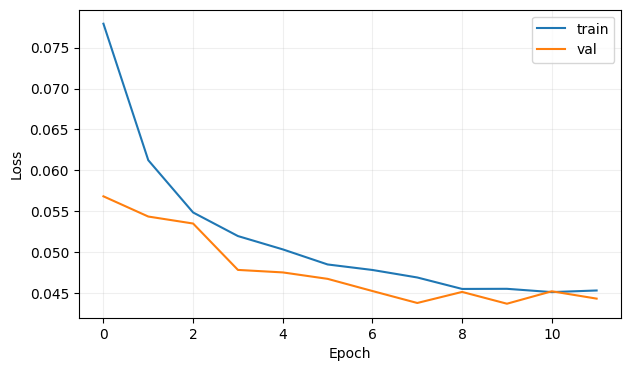

In [22]:
# 11. Plot loss
plt.figure(figsize=(7,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [23]:
# 12. Visual test on a validation pair
model.eval()

hazy, thermal, clean = val_ds[len(val_ds)//2]
with torch.no_grad():
    pred, weights = model(
        hazy.unsqueeze(0).to(device),
        thermal.unsqueeze(0).to(device)
    )

pred = pred[0].cpu().permute(1,2,0).numpy()
hazy_np = hazy.cpu().permute(1,2,0).numpy()
clean_np = clean.cpu().permute(1,2,0).numpy()
thermal_np = thermal[0].cpu().numpy()
w_rgb = weights[0,0].mean().item()
w_ir = weights[0,1].mean().item()

fig, ax = plt.subplots(1,4,figsize=(18,5))
ax[0].imshow(hazy_np); ax[0].set_title("Synthetic hazy RGB")
ax[1].imshow(thermal_np, cmap="inferno"); ax[1].set_title("Thermal")
ax[2].imshow(pred); ax[2].set_title("Enhanced RGB")
ax[3].imshow(clean_np); ax[3].set_title("Target / original RGB")
for a in ax: a.axis("off")
plt.show()

print(f"Mean fusion weight → RGB: {w_rgb:.3f}, Thermal: {w_ir:.3f}")

KeyError: (0, 0)

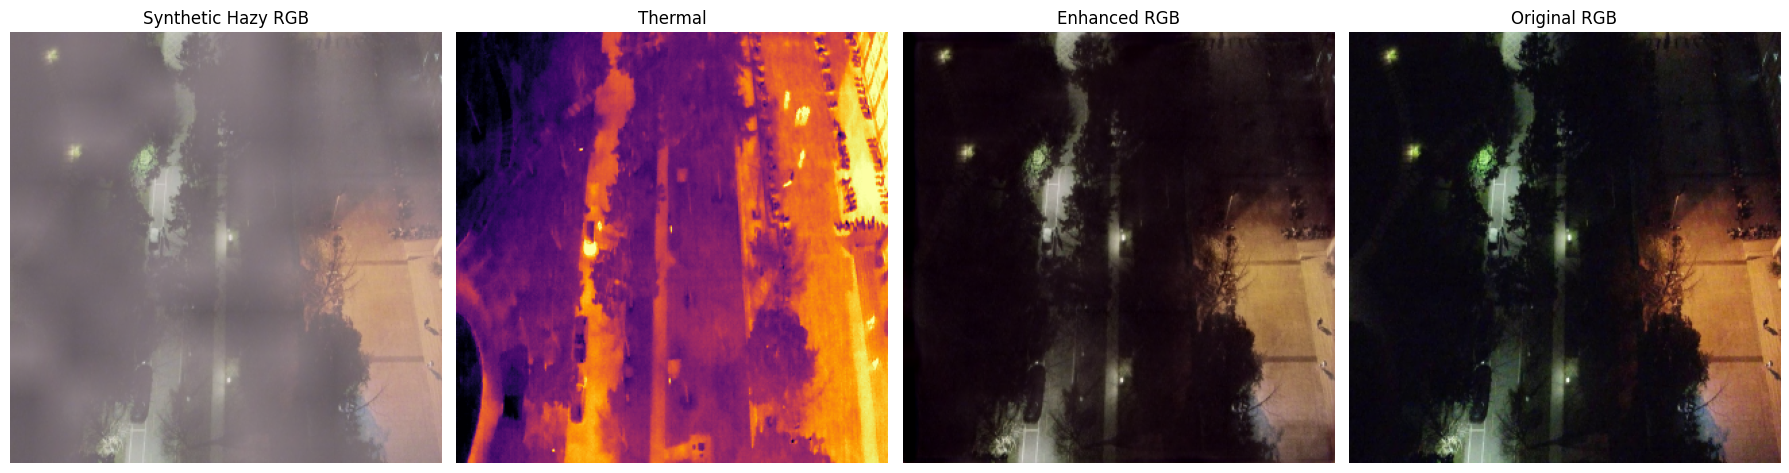

In [25]:

# VISUALIZE RESULT

idx = len(val_ds) // 2

hazy, thermal, clean = val_ds[idx]

with torch.no_grad():

    enhanced, fusion = model(
        hazy.unsqueeze(0).to(device),
        thermal.unsqueeze(0).to(device)
    )

enhanced = (
    enhanced[0]
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

hazy_np = (
    hazy
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

clean_np = (
    clean
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

thermal_np = (
    thermal[0]
    .cpu()
    .numpy()
)


fig, ax = plt.subplots(
    1, 4,
    figsize=(18, 5)
)

ax[0].imshow(hazy_np)
ax[0].set_title("Synthetic Hazy RGB")

ax[1].imshow(
    thermal_np,
    cmap="inferno"
)
ax[1].set_title("Thermal")

ax[2].imshow(
    np.clip(enhanced, 0, 1)
)
ax[2].set_title("Enhanced RGB")

ax[3].imshow(clean_np)
ax[3].set_title("Original RGB")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

scale1: RGB=0.825, Thermal=0.175


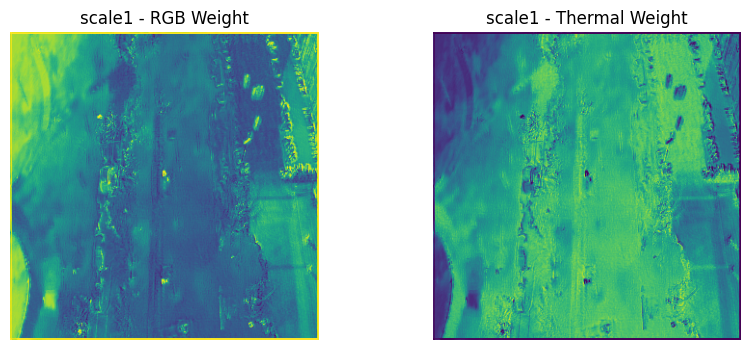

scale2: RGB=0.820, Thermal=0.180


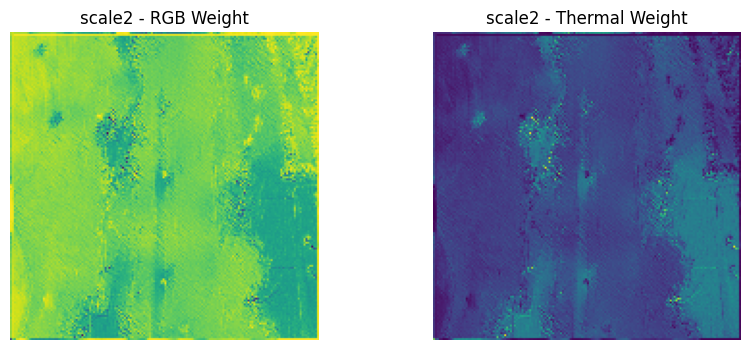

scale3: RGB=0.907, Thermal=0.093


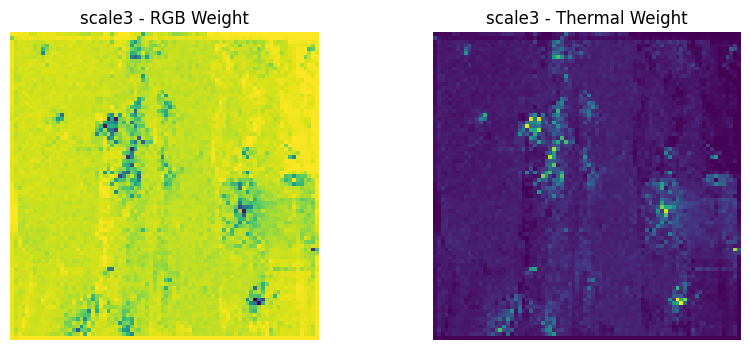

scale4: RGB=0.733, Thermal=0.267


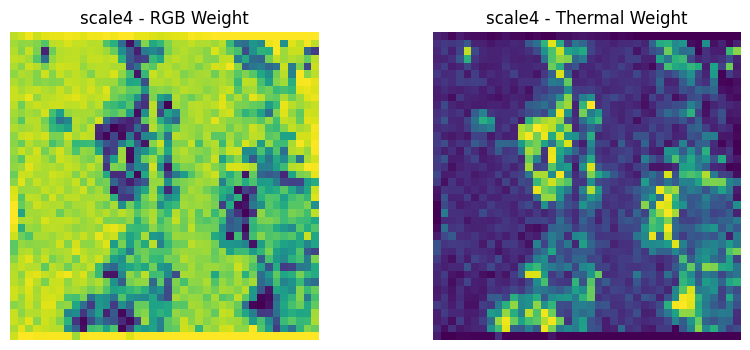

In [26]:

# VISUALIZE FUSION WEIGHTS

for scale_name, weight in fusion.items():

    rgb_weight = (
        weight[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    thermal_weight = (
        weight[0, 1]
        .detach()
        .cpu()
        .numpy()
    )

    print(
        f"{scale_name}: "
        f"RGB={rgb_weight.mean():.3f}, "
        f"Thermal={thermal_weight.mean():.3f}"
    )

    fig, ax = plt.subplots(
        1, 2,
        figsize=(10, 4)
    )

    ax[0].imshow(
        rgb_weight,
        cmap="viridis"
    )

    ax[0].set_title(
        f"{scale_name} - RGB Weight"
    )

    ax[1].imshow(
        thermal_weight,
        cmap="viridis"
    )

    ax[1].set_title(
        f"{scale_name} - Thermal Weight"
    )

    for a in ax:
        a.axis("off")

    plt.show()

## 13. Video inference

Use two synchronized videos:

```text
RGB_VIDEO     = "/content/.../rgb.mp4"
THERMAL_VIDEO = "/content/.../thermal.mp4"
```

The code assumes corresponding frame indices are synchronized/aligned.

For real research, check timestamps/frame rates carefully before assuming frame `t` in one video corresponds exactly to frame `t` in the other.

In [30]:
!rm -rf /content/video && unzip -q /content/drive/MyDrive/Datasets/VTUAV_dataset_segmentation/training/train_001.zip -d /content/video && echo "Done."

Done.


In [31]:

# RGB + THERMAL FRAME SEQUENCE → ENHANCED VIDEO
from pathlib import Path
import cv2
import numpy as np
import torch
import time
from tqdm.auto import tqdm



# 1. PATHS

# Example from your dataset:
VIDEO_DIR = "/content/video/bus_031"

RGB_DIR = os.path.join(VIDEO_DIR, "rgb")
THERMAL_DIR = os.path.join(VIDEO_DIR, "ir")

# Trained NEW U-Net model
MODEL_PATH = "/content/thermal_guided_unet_best.pt"

# Output video
OUTPUT_VIDEO = "/content/bus_031_enhanced.mp4"

# Dataset/video frame rate
# Change this if the original dataset specifies another FPS.
FPS = 30

# Model input size
IMG_SIZE = 320



# 2. CHECK PATHS

if not os.path.isdir(RGB_DIR):
    raise RuntimeError(f"RGB directory not found: {RGB_DIR}")

if not os.path.isdir(THERMAL_DIR):
    raise RuntimeError(f"Thermal directory not found: {THERMAL_DIR}")


# 3. FIND RGB + THERMAL FRAMES

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def find_images(directory):
    files = [
        p for p in Path(directory).iterdir()
        if p.suffix.lower() in IMG_EXTS
    ]

    # Numeric sorting:
    # 000001, 000002, ... 000010
    files = sorted(
        files,
        key=lambda p: int(p.stem)
        if p.stem.isdigit()
        else p.stem
    )

    return files


rgb_files = find_images(RGB_DIR)
thermal_files = find_images(THERMAL_DIR)


print("RGB frames:", len(rgb_files))
print("Thermal frames:", len(thermal_files))


# 4. MATCH FRAMES BY FILENAME

thermal_map = {
    p.stem: p
    for p in thermal_files
}

pairs = []

for rgb_path in rgb_files:

    if rgb_path.stem in thermal_map:

        pairs.append(
            (
                rgb_path,
                thermal_map[rgb_path.stem]
            )
        )


print("Matched RGB-T frames:", len(pairs))


if len(pairs) == 0:
    raise RuntimeError(
        "No matching RGB/Thermal frames found."
    )


# 5. LOAD NEW MODEL

model = ThermalGuidedUNet().to(device)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print("Model loaded successfully.")



# 6. GET ORIGINAL IMAGE SIZE

first_rgb = cv2.imread(
    str(pairs[0][0]),
    cv2.IMREAD_COLOR
)

if first_rgb is None:
    raise RuntimeError(
        f"Cannot read: {pairs[0][0]}"
    )

H, W = first_rgb.shape[:2]

print("Original resolution:", W, "x", H)



# 7. CREATE OUTPUT VIDEO


writer = cv2.VideoWriter(
    OUTPUT_VIDEO,

    cv2.VideoWriter_fourcc(
        *"mp4v"
    ),

    FPS,

    (W, H)
)


if not writer.isOpened():
    raise RuntimeError(
        "Could not create output video."
    )


# 8. PROCESS FRAMES

times = []


with torch.no_grad():

    for rgb_path, thermal_path in tqdm(
        pairs,
        desc="Enhancing RGB-T sequence"
    ):

        start_time = time.perf_counter()



        # RGB


        rgb_bgr = cv2.imread(
            str(rgb_path),
            cv2.IMREAD_COLOR
        )

        if rgb_bgr is None:
            print("Skipping:", rgb_path)
            continue

        rgb = cv2.cvtColor(
            rgb_bgr,
            cv2.COLOR_BGR2RGB
        )



        # THERMAL


        thermal = cv2.imread(
            str(thermal_path),
            cv2.IMREAD_UNCHANGED
        )

        if thermal is None:
            print("Skipping:", thermal_path)
            continue


        # If thermal is stored as RGB/BGR,
        # convert it to one channel.
        if thermal.ndim == 3:

            thermal = cv2.cvtColor(
                thermal,
                cv2.COLOR_BGR2GRAY
            )


        # Convert thermal to float
        thermal = thermal.astype(
            np.float32
        )



        # Thermal normalization


        mn = np.percentile(
            thermal,
            1
        )

        mx = np.percentile(
            thermal,
            99
        )

        thermal = np.clip(
            (thermal - mn) /
            max(mx - mn, 1e-6),
            0,
            1
        )



        # RESIZE


        rgb_small = cv2.resize(
            rgb,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        thermal_small = cv2.resize(
            thermal,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )



        # NUMPY → TORCH


        rgb_tensor = (
            torch.from_numpy(rgb_small)
            .permute(2, 0, 1)
            .float()
            .div(255.0)
            .unsqueeze(0)
            .to(device)
        )


        thermal_tensor = (
            torch.from_numpy(thermal_small)
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )



        # MODEL


        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            enhanced, fusion_info = model(
                rgb_tensor,
                thermal_tensor
            )



        # TORCH → NUMPY


        enhanced = (
            enhanced[0]
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )


        # 0-1 → 0-255
        enhanced = (
            np.clip(
                enhanced,
                0,
                1
            ) * 255
        ).astype(
            np.uint8
        )


        # RESTORE ORIGINAL RESOLUTION

        enhanced = cv2.resize(
            enhanced,
            (W, H),
            interpolation=cv2.INTER_LINEAR
        )


        # RGB → BGR for OpenCV
        enhanced_bgr = cv2.cvtColor(
            enhanced,
            cv2.COLOR_RGB2BGR
        )


        # WRITE FRAME

        writer.write(
            enhanced_bgr
        )


        # TIMING

        elapsed = (
            time.perf_counter()
            - start_time
        )

        times.append(
            elapsed
        )


# 9. CLEAN UP

writer.release()


# 10. PERFORMANCE

if len(times) > 0:

    mean_latency = np.mean(times)

    fps_model = (
        1.0 /
        max(mean_latency, 1e-9)
    )

    print(
        "\nFinished!"
    )

    print(
        f"Output: {OUTPUT_VIDEO}"
    )

    print(
        f"Frames processed: {len(times)}"
    )

    print(
        f"Average model processing: "
        f"{mean_latency*1000:.2f} ms/frame"
    )

    print(
        f"Model processing FPS: "
        f"{fps_model:.2f}"
    )

RGB frames: 1647
Thermal frames: 1647
Matched RGB-T frames: 1647
Model loaded successfully.
Original resolution: 1920 x 1080


Enhancing RGB-T sequence:   0%|          | 0/1647 [00:00<?, ?it/s]


Finished!
Output: /content/bus_031_enhanced.mp4
Frames processed: 1647
Average model processing: 113.26 ms/frame
Model processing FPS: 8.83


In [ ]:
# RGB_VIDEO = "/content/rgb.mp4"
# THERMAL_VIDEO = "/content/thermal.mp4"

# OUTPUT_VIDEO = "/content/enhanced_rgbt_output.mp4"
# MODEL_PATH = "/content/thermal_guided_enhancer.pt"

# # Load trained network
# model = ThermalGuidedEnhancer().to(device)
# model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
# model.eval()

# rgb_cap = cv2.VideoCapture(RGB_VIDEO)
# th_cap = cv2.VideoCapture(THERMAL_VIDEO)

# if not rgb_cap.isOpened():
#     raise RuntimeError(f"Cannot open RGB video: {RGB_VIDEO}")
# if not th_cap.isOpened():
#     raise RuntimeError(f"Cannot open thermal video: {THERMAL_VIDEO}")

# fps = rgb_cap.get(cv2.CAP_PROP_FPS) or 30.0
# W = int(rgb_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# H = int(rgb_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# n_rgb = int(rgb_cap.get(cv2.CAP_PROP_FRAME_COUNT))
# n_th = int(th_cap.get(cv2.CAP_PROP_FRAME_COUNT))
# n = min(n_rgb, n_th)

# writer = cv2.VideoWriter(
#     OUTPUT_VIDEO,
#     cv2.VideoWriter_fourcc(*"mp4v"),
#     fps,
#     (W, H)
# )

# times = []
# with torch.no_grad():
#     for _ in tqdm(range(n), desc="Enhancing video"):
#         ok1, rgb_bgr = rgb_cap.read()
#         ok2, th_raw = th_cap.read()
#         if not ok1 or not ok2:
#             break

#         t0 = time.perf_counter()

#         # RGB
#         rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)

#         # Thermal
#         if th_raw.ndim == 3:
#             th_raw = cv2.cvtColor(th_raw, cv2.COLOR_BGR2GRAY)
#         th = th_raw.astype(np.float32)
#         mn, mx = np.percentile(th, 1), np.percentile(th, 99)
#         th = np.clip((th - mn) / max(mx - mn, 1e-6), 0, 1)

#         # Resize both to model size; alignment is preserved because
#         # the two streams are already registered in your data.
#         rgb_small = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
#         th_small = cv2.resize(th, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

#         rgb_t = torch.from_numpy(rgb_small).permute(2,0,1).float().div(255).unsqueeze(0).to(device)
#         th_t = torch.from_numpy(th_small).float().unsqueeze(0).unsqueeze(0).to(device)

#         with torch.autocast(device_type=device.type, dtype=torch.float16,
#                             enabled=(device.type == "cuda")):
#             enhanced, _ = model(rgb_t, th_t)

#         out = enhanced[0].cpu().permute(1,2,0).numpy()
#         out = (np.clip(out,0,1)*255).astype(np.uint8)
#         out = cv2.resize(out, (W,H), interpolation=cv2.INTER_LINEAR)
#         out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)

#         writer.write(out_bgr)
#         times.append(time.perf_counter() - t0)

# rgb_cap.release()
# th_cap.release()
# writer.release()

# mean_latency = np.mean(times)
# fps_model = 1.0 / max(mean_latency, 1e-9)
# print(f"Saved: {OUTPUT_VIDEO}")
# print(f"Model-only processing FPS: {fps_model:.2f}")

## 14. Optional: add YOLO11n detection on the enhanced video

This is a **demo detector** using a pretrained detector.

For real accuracy measurements, fine-tune the detector on RGB-T UAV annotations. Do not treat pretrained COCO accuracy as your research result.

In [ ]:
from ultralytics import YOLO

detector = YOLO("yolo11n.pt")
print("Loaded YOLO11n")

In [ ]:
# 15. Run enhancement + YOLO detection together

DETECTION_OUTPUT = "/content/rgbt_enhanced_detected.mp4"

rgb_cap = cv2.VideoCapture(RGB_VIDEO)
th_cap = cv2.VideoCapture(THERMAL_VIDEO)

fps = rgb_cap.get(cv2.CAP_PROP_FPS) or 30.0
W = int(rgb_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(rgb_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n = min(
    int(rgb_cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    int(th_cap.get(cv2.CAP_PROP_FRAME_COUNT))
)

writer = cv2.VideoWriter(
    DETECTION_OUTPUT,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (W,H)
)

times = []

for _ in tqdm(range(n), desc="Enhancement + detection"):
    ok1, rgb_bgr = rgb_cap.read()
    ok2, th_raw = th_cap.read()
    if not ok1 or not ok2:
        break

    t0 = time.perf_counter()

    rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)

    if th_raw.ndim == 3:
        th_raw = cv2.cvtColor(th_raw, cv2.COLOR_BGR2GRAY)
    th = th_raw.astype(np.float32)
    mn, mx = np.percentile(th, 1), np.percentile(th, 99)
    th = np.clip((th-mn)/max(mx-mn,1e-6),0,1)

    rgb_small = cv2.resize(rgb, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
    th_small = cv2.resize(th, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)

    rgb_t = torch.from_numpy(rgb_small).permute(2,0,1).float().div(255).unsqueeze(0).to(device)
    th_t = torch.from_numpy(th_small).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.autocast(device_type=device.type, dtype=torch.float16,
                            enabled=(device.type == "cuda")):
            enhanced, _ = model(rgb_t, th_t)

    enhanced_rgb = enhanced[0].cpu().permute(1,2,0).numpy()
    enhanced_rgb = (np.clip(enhanced_rgb,0,1)*255).astype(np.uint8)
    enhanced_bgr = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2BGR)
    enhanced_bgr = cv2.resize(enhanced_bgr, (W,H), interpolation=cv2.INTER_LINEAR)

    # YOLO inference on enhanced RGB.
    result = detector.predict(
        source=enhanced_bgr,
        imgsz=640,
        conf=0.25,
        device=0 if device.type=="cuda" else "cpu",
        verbose=False
    )[0]

    annotated = result.plot()

    times.append(time.perf_counter() - t0)
    writer.write(annotated)

rgb_cap.release()
th_cap.release()
writer.release()

print("Saved:", DETECTION_OUTPUT)
print("End-to-end FPS:", 1.0/np.mean(times))

<!-- # 16. Recommended datasets / video sources

### A. DUT-VTUAV — best choice for your VIDEO experiment

CVPR 2022 benchmark with **nearly 1.7 million well-aligned RGB-T image pairs across 500 sequences**. It is specifically designed for visible-thermal UAV tracking and provides a Google Drive download route in the official repository.

Official repository:
https://github.com/zhang-pengyu/DUT-VTUAV

### B. UAV RGB-T 2400 — useful aligned UAV paired images

Captured with a DJI Mavic 2 Enterprise Advanced. The project states that RGB and thermal videos were recorded simultaneously, and the image pairs were manually matched so that the modalities correspond.

Official repository:
https://github.com/VDT-2048/UAV-RGB-T-2400

### C. DRTV30K — very recent UAV RGB-T detection benchmark

Released July 1, 2026. It contains **30,640 RGB-T pairs**, oriented bounding boxes, 7 standard vehicle categories + 2 rare categories, and data from daytime, nighttime, dark-night and foggy scenes. It also documents **232 paired UAV videos** used in collection.

Official repository:
https://github.com/Vehicle-AHU/DRTV30K

Note: although it was center-aligned, it intentionally retains local RGB-T discrepancies. That makes it useful for robust multimodal detection, but it is not identical to your perfectly aligned setup.

### D. DroneVehicle — established UAV RGB-IR detection benchmark

Contains **28,439 RGB-IR image pairs / 56,878 individual images**, with 5 vehicle categories and day/night coverage.

Official repository:
https://github.com/VisDrone/DroneVehicle

### E. LLVIP — low-light RGB/IR pairs

Useful for testing the low-light part of your pipeline. It contains **30,976 visible-infrared images** in the released version and also has raw unregistered pairs/videos.

Official repository:
https://github.com/bupt-ai-cz/LLVIP

### F. HIT-UAV — UAV thermal detection

Useful for thermal-only detection baselines. It has **2,898 thermal images extracted from 43,470 UAV frames**, covering day/night and 60–130 m altitude.

Official repository:
https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset -->

<!-- # 17. Suggested experiment sequence

Run these in order:

1. RGB-only YOLO11n
2. RGB + thermal early fusion
3. dual-stream + gated fusion
4. dual-stream + difference fusion
5. thermal-guided enhancement
6. enhancement + YOLO11n
7. temporal enhancement on video

Report:

- mAP@0.5
- mAP@0.5:0.95
- small-object AP
- precision / recall
- FPS
- end-to-end latency
- parameter count
- GFLOPs
- GPU memory
- results split by clear / haze / low-light / night

For the final research model, add a **detection loss** and train the enhancement/fusion module jointly with the detector. This notebook deliberately starts with the simpler reconstruction stage so that debugging is easier. -->